<a href="https://colab.research.google.com/github/Aishwaryaselvaraju/CODSOFT/blob/main/Codsoft_Task_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


**Project:** Titanic Survival Prediction using Machine Learning

**Dataset Source:** Titanic Dataset (Kaggle)

**Description:** This project predicts whether a passenger survived the Titanic disaster using passenger data like age, gender, class, fare, and embarkation point.

**Tools Used:** Python, Pandas, Seaborn, Scikit-Learn, Matplotlib

# Installing Required Libraries



In [ ]:
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install seaborn
!pip install scikit-learn

# Import Required Libraries

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load the Dataset

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Titanic.csv to Titanic.csv


In [ ]:
df = pd.read_csv("Titanic.csv")
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Data Understanding

In [ ]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


# Data visualization

<Axes: xlabel='Survived', ylabel='count'>

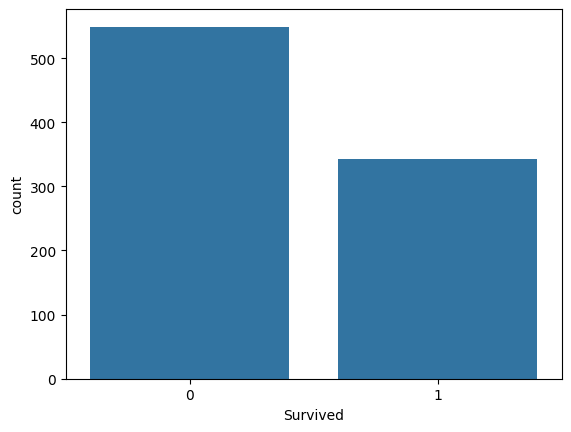

In [ ]:
sns.countplot(x='Survived', data=df)

In [ ]:
print(df.columns.tolist())


['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


# Handle Missing Values

In [ ]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])


# Encode categorical columns

In [ ]:
le = LabelEncoder()

if df['Sex'].dtype == 'object':
    df['Sex'] = le.fit_transform(df['Sex'])

if df['Embarked'].dtype == 'object':
    df['Embarked'] = le.fit_transform(df['Embarked'])

# Drop unwanted string columns (like 'Name', 'Ticket', 'Cabin')

In [ ]:
df = df.drop(columns=['Name', 'Ticket', 'Cabin', 'PassengerId'], errors='ignore')

# Step 3: Split into X and y
X = df.drop('Survived', axis=1)
y = df['Survived']

# Remove any non-numeric columns just in case

In [ ]:
X = X.select_dtypes(include=['int64', 'float64'])


# Scale the features

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

# Logistic Regression

In [ ]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

# Model Evaluation

Accuracy: 0.8044692737430168
Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.86      0.84       105
           1       0.78      0.73      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.80      0.80      0.80       179



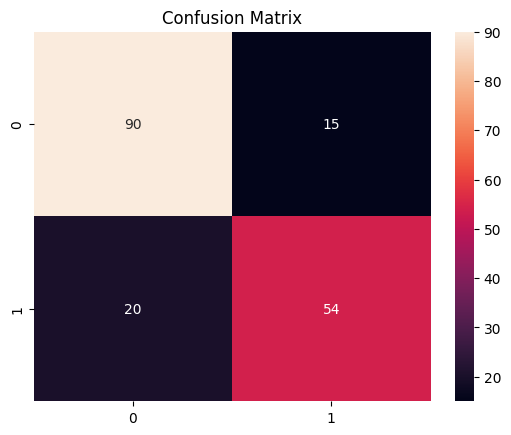

In [ ]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()


In [ ]:
coefficients = pd.DataFrame(model.coef_[0], index=X.columns, columns=['Coefficient'])
coefficients.sort_values(by='Coefficient', ascending=False)

,Coefficient
Fare,0.121214
Parch,-0.100018
Embarked,-0.174770
SibSp,-0.328189
Age,-0.395757
Pclass,-0.792517
Sex,-1.285813


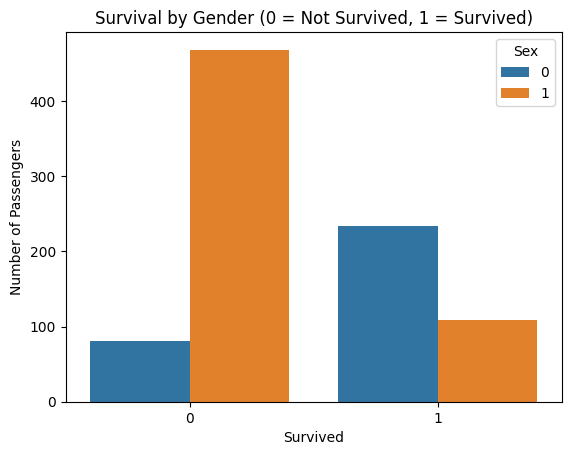

In [ ]:
sns.countplot(x='Survived', hue='Sex', data=df)
plt.title("Survival by Gender (0 = Not Survived, 1 = Survived)")
plt.xlabel("Survived")
plt.ylabel("Number of Passengers")
plt.show()


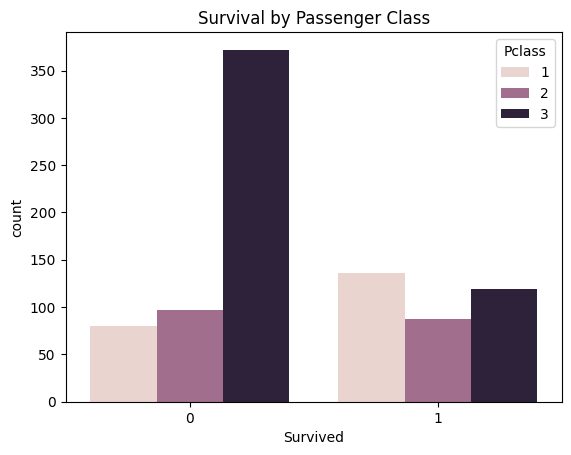

In [ ]:
sns.countplot(x='Survived', hue='Pclass', data=df)
plt.title("Survival by Passenger Class")
plt.show()


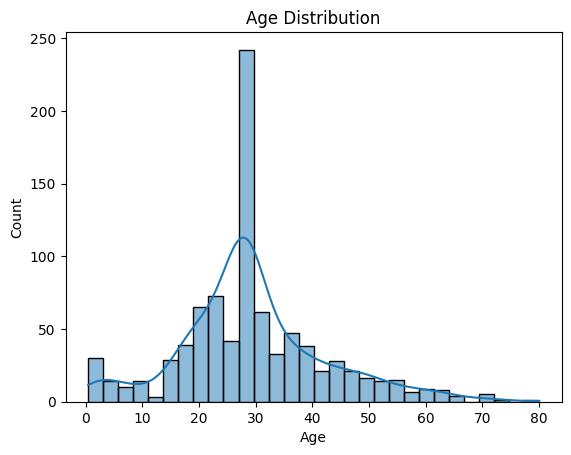

In [ ]:
sns.histplot(df['Age'], kde=True)
plt.title("Age Distribution")
plt.show()


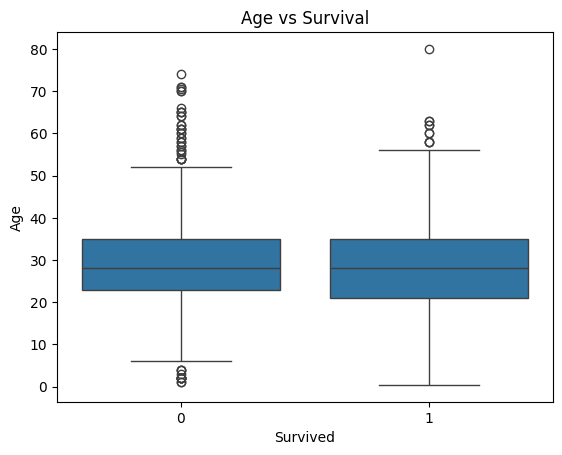

In [ ]:
sns.boxplot(x='Survived', y='Age', data=df)
plt.title("Age vs Survival")
plt.show()


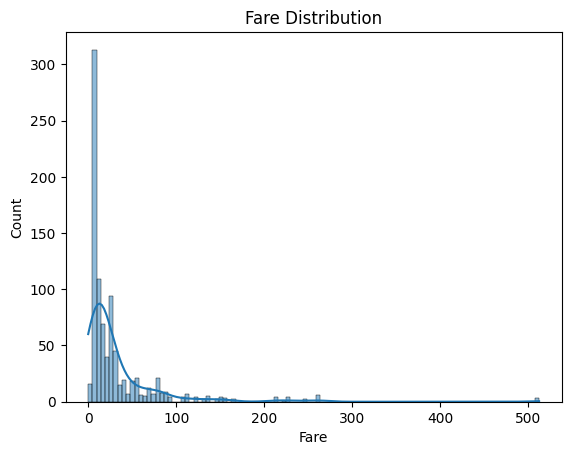

In [ ]:
sns.histplot(df['Fare'], kde=True)
plt.title("Fare Distribution")
plt.show()


In [ ]:
import joblib
joblib.dump(model, 'titanic_survival_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
print("RF Accuracy:", accuracy_score(y_test, rf.predict(X_test)))

RF Accuracy: 0.8156424581005587
